# Baseline CNN

In this notebook we will create a simple baseline CNN, with only a couple of layers to validate that everything is working as expected and establish a baseline result before moving into architectural exploration.

## 0. Imports and GPU Configuration

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import keras
from keras import layers

2026-04-16 23:49:30.898979: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776379770.923828  396357 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776379770.932854  396357 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776379770.960833  396357 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776379770.960882  396357 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776379770.960886  396357 computation_placer.cc:177] computation placer alr

Check if our GPU is detected

In [2]:
gpus = tf.config.list_physical_devices('GPU')
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Configure memory limit to take advantage of all of our VRAM

In [3]:
for gpu in gpus:
    tf.config.set_logical_device_configuration(
        gpu,
        [tf.config.LogicalDeviceConfiguration(memory_limit=round(3.8*1024))]
    )

## 1. Data import

In [4]:
image_size = (128, 128) # the original images are 512x512 but we resize them to save memory while training
batch_size = 16 # let's start small as we have not a lot of VRAM
n_classes = 23

train_ds = keras.utils.image_dataset_from_directory(
    "../Data/Train",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds = keras.utils.image_dataset_from_directory(
    "../Data/Validation",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical"
)

test_ds = keras.utils.image_dataset_from_directory(
    "../Data/Test",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical"
)

Found 9338 files belonging to 23 classes.


I0000 00:00:1776379776.603028  396357 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3891 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2001 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.


## 2. Baseline architecture

Let's create a simple architecture with some convolutional layers, organized in blocks of 2 or 3 layers followed by a max pooling layer and a classifier head

In [23]:
class BaselineModel(keras.Model):
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
        self.augmentation = layers.Pipeline(
            [
                layers.RandomFlip("horizontal"),
                layers.RandomBrightness(factor=0.08, value_range=(0.0, 1.0)),
                layers.RandomContrast(factor=0.08),
                layers.RandomRotation(factor=0.02, fill_mode="reflect"),
                layers.RandomZoom((-0.05, 0.05), fill_mode="reflect"),
                layers.RandomTranslation(
                    height_factor=0.05, width_factor=0.05, fill_mode="reflect"
                ),
                layers.GaussianNoise(stddev=0.02),
            ],
            name="augmentation_moderate_noise",
        )
        self.rescaling = layers.Rescaling(1./255)
        
        self.conv1 = layers.Conv2D(128, 3, activation="relu")
        self.conv2 = layers.Conv2D(128, 3, activation="relu")
        self.max_pooling1 = layers.MaxPooling2D(2)
        
        self.conv3 = layers.Conv2D(256, 3, activation="relu")
        self.conv4 = layers.Conv2D(256, 3, activation="relu")
        self.max_pooling2 = layers.MaxPooling2D(2)
        
        self.conv5 = layers.Conv2D(256, 3, activation="relu")
        self.conv6 = layers.Conv2D(256, 3, activation="relu")
        self.max_pooling3 = layers.MaxPooling2D(2)
        
        self.conv7 = layers.Conv2D(512, 3, activation="relu")
        self.conv8 = layers.Conv2D(512, 3, activation="relu")
        self.max_pooling4 = layers.MaxPooling2D(2)
        
        self.global_average_pooling = layers.GlobalAveragePooling2D()
        self.dropout = layers.Dropout(0.2)
        self.classifier = layers.Dense(n_classes, activation="softmax")
        
    def call(self, inputs, training=False):
        x = self.rescaling(inputs)
        
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.max_pooling1(x)
        
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.max_pooling2(x)
        
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.max_pooling3(x)
        
        x = self.conv7(x)
        x = self.conv8(x)
        x = self.max_pooling4(x)
        
        x = self.global_average_pooling(x)
        x = self.dropout(x)
        outputs = self.classifier(x)
        return outputs

In [24]:
baseline_model = BaselineModel()

Let's check the shape layers and output shapes

In [25]:
inputs = keras.Input(shape=image_size + (3,))
_ = baseline_model.call(inputs)
baseline_model.summary()

Model: "baseline_model_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_moderate_noise     │ ?                      │   0 (unbuilt) │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 126, 126, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 124, 124, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 58, 58, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 29, 29, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 27, 27, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │        11,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,768,343 (22.00 MB)

 Trainable params: 5,768,343 (22.00 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Baseline model training

Now that we have created a simple base model, let's compile and train it

In [ ]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score("macro")
    ]
)

In [27]:
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", patience=2)
)

Epoch 1/10


/root/miniforge3/envs/DL2526/lib/python3.11/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'baseline_model_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


584/584 ━━━━━━━━━━━━━━━━━━━━ 112s 187ms/step - categorical_accuracy: 0.1267 - f1_score: 0.0394 - loss: 2.9640 - val_categorical_accuracy: 0.1539 - val_f1_score: 0.0528 - val_loss: 2.8713
Epoch 2/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 108s 185ms/step - categorical_accuracy: 0.1822 - f1_score: 0.0863 - loss: 2.7692 - val_categorical_accuracy: 0.2034 - val_f1_score: 0.0880 - val_loss: 2.7119
Epoch 3/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 108s 185ms/step - categorical_accuracy: 0.2221 - f1_score: 0.1259 - loss: 2.6345 - val_categorical_accuracy: 0.2389 - val_f1_score: 0.1446 - val_loss: 2.5203
Epoch 4/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 108s 185ms/step - categorical_accuracy: 0.2592 - f1_score: 0.1755 - loss: 2.4802 - val_categorical_accuracy: 0.2799 - val_f1_score: 0.1980 - val_loss: 2.4438
Epoch 5/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 108s 185ms/step - categorical_accuracy: 0.3067 - f1_score: 0.2353 - loss: 2.3203 - val_categorical_accuracy: 0.3288 - val_f1_score: 0.2680 - val_loss: 2.2704
Epoch 6/10
584/584 ━━

In [28]:
baseline_history2 = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=10,
    epochs=20,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", patience=2)
)

Epoch 11/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 107s 184ms/step - categorical_accuracy: 0.4395 - f1_score: 0.3877 - loss: 1.8383 - val_categorical_accuracy: 0.4298 - val_f1_score: 0.3777 - val_loss: 1.9073
Epoch 12/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 109s 186ms/step - categorical_accuracy: 0.4563 - f1_score: 0.4086 - loss: 1.7769 - val_categorical_accuracy: 0.4233 - val_f1_score: 0.3728 - val_loss: 1.9154
Epoch 13/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 109s 186ms/step - categorical_accuracy: 0.4707 - f1_score: 0.4217 - loss: 1.7263 - val_categorical_accuracy: 0.4378 - val_f1_score: 0.3841 - val_loss: 1.8801
Epoch 14/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 109s 186ms/step - categorical_accuracy: 0.4876 - f1_score: 0.4402 - loss: 1.6646 - val_categorical_accuracy: 0.4493 - val_f1_score: 0.4073 - val_loss: 1.8486
Epoch 15/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 109s 186ms/step - categorical_accuracy: 0.5106 - f1_score: 0.4655 - loss: 1.5970 - val_categorical_accuracy: 0.4563 - val_f1_score: 0.4190 - val_loss: 1.8430
Epoch

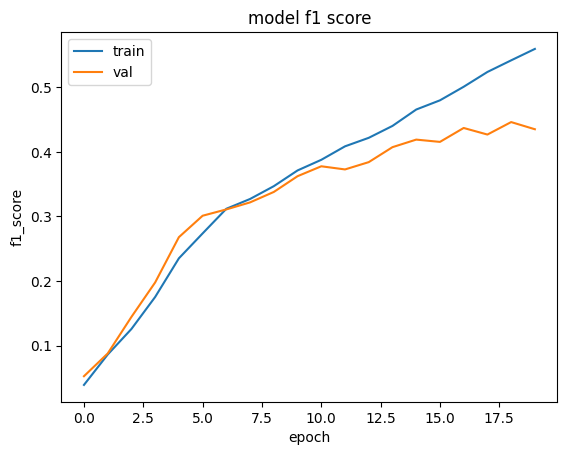

In [31]:
baseline_f1_score =  baseline_history.history["f1_score"] + baseline_history2.history["f1_score"]
baseline_val_f1_score = baseline_history.history["val_f1_score"] + baseline_history2.history["val_f1_score"]

plt.plot(baseline_f1_score)
plt.plot(baseline_val_f1_score)
plt.title('model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Let's now save the model to a .keras file so that we can use it in in other notebooks for comparison

In [32]:
baseline_model.save("../outputs/models/baseline_cnn.keras")

## 4. Baseline model evaluation